# 04 - Modelado y pronóstico del consumo eléctrico

En este cuaderno se entrena y evalúa un modelo de regresión para predecir la potencia activa global a nivel horario utilizando las características temporales generadas previamente.

In [2]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

%matplotlib inline
sns.set(style="whitegrid")

## Carga de datos enriquecidos para modelado

In [3]:
features_path = Path("..") / "data" / "household_power_consumption_features_hourly.csv"
df = pd.read_csv(features_path)

df.head()

,datetime,Date,Time,Global_active_power,Global_reactive_power,Voltage,Global_intensity,Sub_metering_1,Sub_metering_2,Sub_metering_3,hour,day_of_week,is_weekend,lag_1,lag_24,rolling_mean_24
0,2006-12-16 17:48:00,16/12/2006,17:48:00,4.474,0.0,234.96,19.4,0.0,0.0,17.0,17,5,1,5.174,4.216,4.574917
1,2006-12-16 17:49:00,16/12/2006,17:49:00,3.248,0.0,236.66,13.6,0.0,0.0,17.0,17,5,1,4.474,5.360,4.486917
2,2006-12-16 17:50:00,16/12/2006,17:50:00,3.236,0.0,235.84,13.6,0.0,0.0,17.0,17,5,1,3.248,5.374,4.397833
3,2006-12-16 17:51:00,16/12/2006,17:51:00,3.228,0.0,235.60,13.6,0.0,0.0,17.0,17,5,1,3.236,5.388,4.307833
4,2006-12-16 17:52:00,16/12/2006,17:52:00,3.258,0.0,235.49,13.8,0.0,0.0,17.0,17,5,1,3.228,3.666,4.290833


In [5]:
df.columns

Index(['datetime', 'Date', 'Time', 'Global_active_power',
       'Global_reactive_power', 'Voltage', 'Global_intensity',
       'Sub_metering_1', 'Sub_metering_2', 'Sub_metering_3', 'hour',
       'day_of_week', 'is_weekend', 'lag_1', 'lag_24', 'rolling_mean_24'],
      dtype='str')

## Definición de variables de entrada y objetivo

In [6]:

gap_col = [c for c in df.columns if c.lower() == "global_active_power"][0]

feature_cols = [
    "hour",
    "day_of_week",
    "is_weekend",
    "lag_1",
    "lag_24",
    "rolling_mean_24",
]

X = df[feature_cols].copy()
y = df[gap_col].copy()

X.shape, y.shape

((2049256, 6), (2049256,))

## División entrenamiento / prueba respetando el orden temporal

In [7]:
split_idx = int(len(X) * 0.8)

X_train, X_test = X.iloc[:split_idx], X.iloc[split_idx:]
y_train, y_test = y.iloc[:split_idx], y.iloc[split_idx:]

X_train.shape, X_test.shape

((1639404, 6), (409852, 6))

## Entrenamiento de un modelo Random Forest Regressor

In [9]:
# Reduce memory footprint: fewer trees and single-threaded fitting
model = RandomForestRegressor(
    n_estimators=50,      # fewer trees → lower memory usage
    random_state=42,
    n_jobs=1,             # disable parallel jobs to avoid extra memory forks
    max_depth=10,         # cap tree depth
    max_features="sqrt",  # limit features considered at each split
)

model.fit(X_train, y_train)


,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",50
,"criterion criterion: {""squared_error"", ""absolute_error"", ""friedman_mse"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""friedman_mse"", which usesmean squared error with Friedman's improvement score for potentialsplits, ""absolute_error"" for the mean absolute error, which minimizesthe L1 loss using the median of each terminal node, and ""poisson"" whichuses reduction in Poisson deviance to find splits.Training using ""absolute_error"" is significantly slowerthan when using ""squared_error""... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion.",'squared_error'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",10
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsample

## Evaluación del modelo en el conjunto de prueba

In [11]:
y_pred = model.predict(X_test)

mae = mean_absolute_error(y_test, y_pred)
rmse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

mae, rmse, r2


(0.09581899583188967, 0.0496958825012301, 0.9381004405655359)

## Comparación visual entre valores reales y predichos

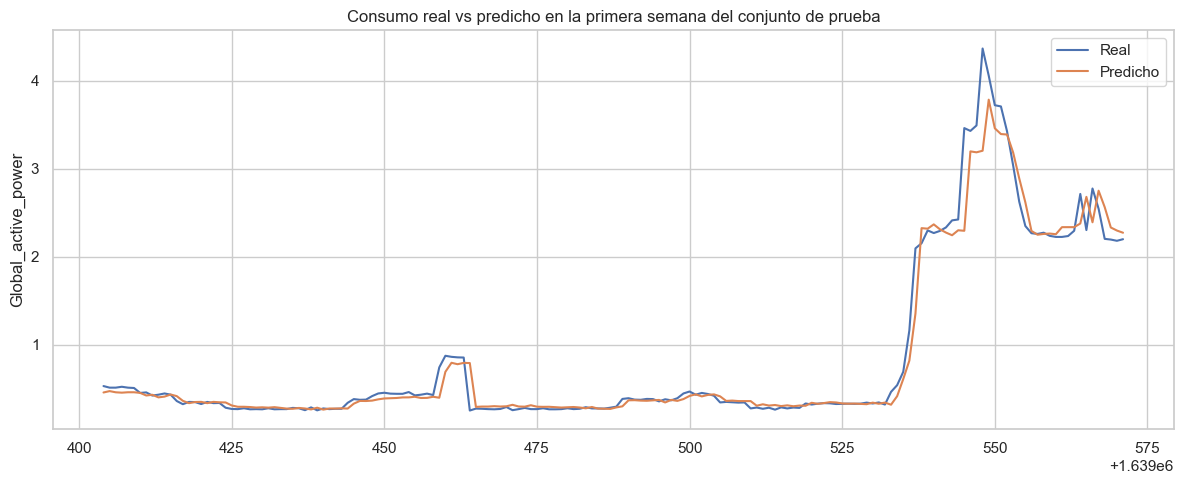

In [12]:
results = pd.DataFrame({"y_test": y_test, "y_pred": y_pred}, index=y_test.index)

sample = results.iloc[:24 * 7]

plt.figure(figsize=(12, 5))
sample["y_test"].plot(label="Real")
sample["y_pred"].plot(label="Predicho")
plt.ylabel(gap_col)
plt.title("Consumo real vs predicho en la primera semana del conjunto de prueba")
plt.legend()
plt.tight_layout()

## Importancia de características

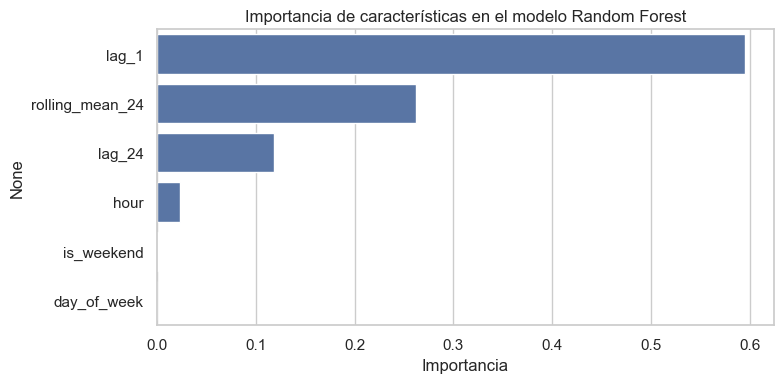

In [13]:
importances = pd.Series(model.feature_importances_, index=feature_cols).sort_values(ascending=False)

plt.figure(figsize=(8, 4))
sns.barplot(x=importances.values, y=importances.index)
plt.title("Importancia de características en el modelo Random Forest")
plt.xlabel("Importancia")
plt.tight_layout()